In [ ]:
#some kmeans and agglomerative action
# firstly upload the files to e worked with and then start doing the things on q2 and the others

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content/drive/MyDrive/Colab Notebooks'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/content/drive/MyDrive/Colab Notebooks/movies_metadata.csv
/content/drive/MyDrive/Colab Notebooks/ratings_small.csv
/content/drive/MyDrive/Colab Notebooks/data_test.csv
/content/drive/MyDrive/Colab Notebooks/data_train.csv
/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb
/content/drive/MyDrive/Colab Notebooks/clusteringandevaluation.ipynb
/content/drive/MyDrive/Colab Notebooks/links_small.csv
/content/drive/MyDrive/Colab Notebooks/clusteringandcategorizing.ipynb


# kmeans and agglomerative (question 2)

In [3]:
import pandas as pd

df_links = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/links_small.csv')
df_movie_metadata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/movies_metadata.csv')
df_ratings = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ratings_small.csv')

/tmp/ipython-input-3667154614.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df_movie_metadata = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/movies_metadata.csv')


In [ ]:
df_movie_metadata.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [ ]:
df_movie_metadata['vote_count']

,vote_count
0,5415.0
1,2413.0
2,92.0
3,34.0
4,173.0
...,...
45461,1.0
45462,3.0
45463,6.0
45464,0.0


In [4]:
movie_metadata = df_movie_metadata[df_movie_metadata["vote_count"] >= 10]

In [ ]:
#df_links.head()
movie_metadata.imdb_id.head()

,imdb_id
0,tt0114709
1,tt0113497
2,tt0113228
3,tt0114885
4,tt0113041


In [6]:
links_clean = df_links.dropna(subset=["imdbId"]).copy()

links_clean["imdb_id"] = (
    "tt" +
    links_clean["imdbId"].astype(int).astype(str).str.zfill(7)
)



In [ ]:
links_clean.head()[["movieId","imdb_id"]]

,movieId,imdb_id
0,1,tt0114709
1,2,tt0113497
2,3,tt0113228
3,4,tt0114885
4,5,tt0113041


In [7]:
movies_merged = links_clean.merge(
    movie_metadata,
    on="imdb_id",
    how="inner"
)

In [8]:
movies_valid = movies_merged[movies_merged["vote_count"] >= 20]

In [9]:
df_use = df_ratings.merge(
    movies_valid[["movieId"]],
    on="movieId",
    how="inner"
)

In [ ]:
df_use.shape
df_use.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [10]:
import numpy as np
from scipy.sparse import csr_matrix

unique_users  = df_use["userId"].unique()
unique_movies = df_use["movieId"].unique()

user_index  = {u:i for i,u in enumerate(unique_users)}
movie_index = {m:i for i,m in enumerate(unique_movies)}

rows = df_use["movieId"].map(movie_index).values
cols = df_use["userId"].map(user_index).values
vals = df_use["rating"].values

R = csr_matrix((vals, (rows, cols)),
               shape=(len(unique_movies), len(unique_users)))


In [ ]:
print(R.shape)

(7443, 671)


In [11]:
from sklearn.decomposition import TruncatedSVD

k_components = 50   # typical values: 20–200
svd = TruncatedSVD(n_components=k_components, random_state=42)
R_reduced = svd.fit_transform(R)   # dense (num_users , 50)

In [12]:
from sklearn.cluster import KMeans

K = 10   # number of clusters
kmeans = KMeans(n_clusters=K, random_state=42)
user_clusters = kmeans.fit_predict(R_reduced)

In [13]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=K,
    metric="euclidean",       # or "cosine" in newer sklearn
    linkage="ward"            # if cosine, use "average"
)

user_clusters_agg = agg.fit_predict(R_reduced)


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [15]:
K_range = range(2, 21)   # silhouette undefined for K=1

sse = []
sil_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(R_reduced)

    # SSE
    sse.append(kmeans.inertia_)

    # Silhouette score
    sil = silhouette_score(R_reduced, labels, metric="euclidean")
    sil_scores.append(sil)


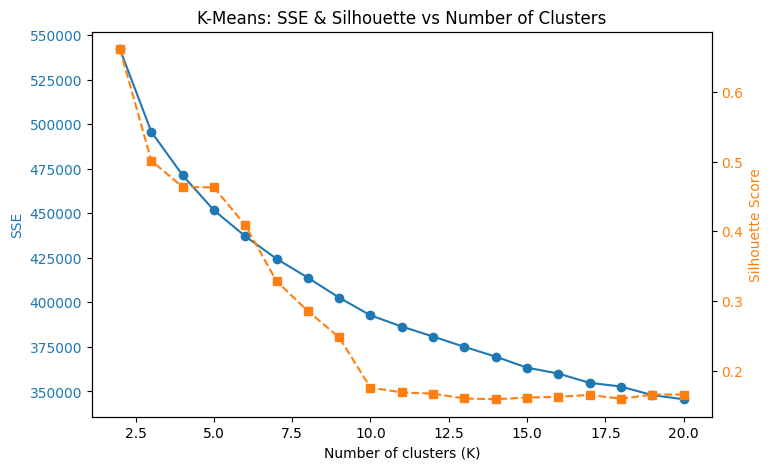

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 5))
# Left y-axis - SSE
ax1.plot(K_range, sse, 'o-', color='tab:blue', label='SSE (Inertia)')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('SSE', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Right y-axis - Silhouette
ax2 = ax1.twinx()
ax2.plot(K_range, sil_scores, 's--', color='tab:orange', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='tab:orange')
ax2.tick_params(axis='y', labaelcolor='tab:orange')

# Title
plt.title('K-Means: SSE & Silhouette vs Number of Clusters')

plt.show()


Το καλύτερο k (αριθμός cluster) επιτυγχάνεται για k = 20 χρησιμοποιώντας τον αλγόριθμο kmeans, καθώς για k=20 παρατηρούμε το ζευγάρι με τα μικρότερα νούμερα sse και silhouette score, κάτι το οποίο τα καθιστά ως τα καλύτερα score.

In [ ]:
K_range = range(2, 21)   # silhouette undefined for K=1

sse = []
sil_scores = []

for k in K_range:
    agg = AgglomerativeClustering(
    n_clusters=K,
    metric="euclidean",       # or "cosine" in newer sklearn
    linkage="ward"            # if cosine, use "average"
)
    labels = agg.fit_predict(R_reduced)

    # Silhouette score
    sil = silhouette_score(R_reduced, labels, metric="euclidean")
    sil_scores.append(sil)

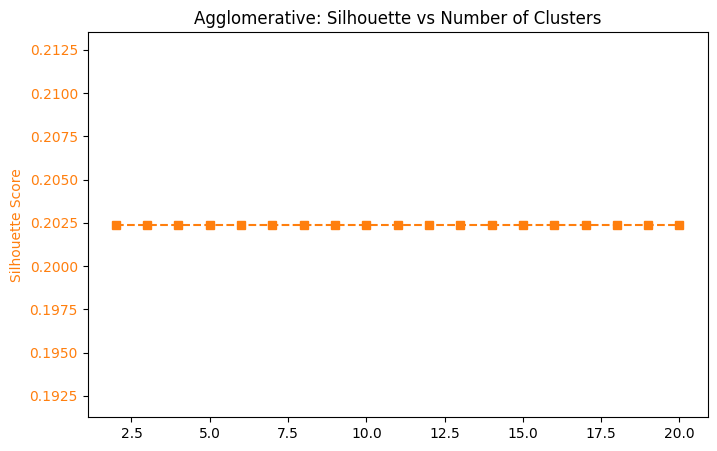

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 5))
# Left y-axis → SSE
ax1.plot(K_range, sse, 'o-', color='tab:blue', label='SSE (Inertia)')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('SSE', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Title
plt.title('Agglomerative: Silhouette vs Number of Clusters')

plt.show()

In [89]:
# computing labels for best k for both agglomerative and kmeans: (k=20)

kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
labels = kmeans.fit_predict(R_reduced)
user_clusters = kmeans.fit_predict(R_reduced)

agg = AgglomerativeClustering(
    n_clusters=20,
    metric="euclidean",       # or "cosine" in newer sklearn
    linkage="ward"            # if cosine, use "average"
)
labels = agg.fit_predict(R_reduced)
user_clusters_agg = agg.fit_predict(R_reduced)


In [90]:
import ast

def parse_genres(x):
    if isinstance(x, str):
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            return []
    return x if isinstance(x, list) else []


df_movie_metadata2 = df_movie_metadata.copy()
df_movie_metadata2['genres'] = df_movie_metadata2['genres'].apply(parse_genres)

genres_list = df_movie_metadata2['genres'].apply(
    lambda lst: [g['name'] for g in lst]
)

In [91]:
# Should all be lists
print(genres_list.apply(type).value_counts())

# No nested lists allowed
nested = any(
    any(isinstance(g, list) for g in lst)
    for lst in genres_list
)
print("Nested lists:", nested)

genres
<class 'list'>    45466
Name: count, dtype: int64
Nested lists: False


In [105]:
df_movie_metadata2.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [106]:
df_use.head()

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


# categorization algorithm application (question 3)

In [ ]:
#by using movie metadata, we predict genre of movie based on overview (train with overview)

In [ ]:
#genres to be used: War, Music, Animation

In [ ]:
df_movie_metadata.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [16]:
print(type(df_movie_metadata.loc[0,"genres"])) #is str, so needs to be transformed into dict in order to parse

import ast

movie_metadata2 = df_movie_metadata.copy()

movie_metadata2["genres_parsed"] = movie_metadata2["genres"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

target_genres = {"War", "Music", "Animation"}

movie_metadata2["genre_names"] = movie_metadata2["genres_parsed"].apply(
    lambda lst: {g["name"] for g in lst}
)

df_filtered = movie_metadata2[
    movie_metadata2["genre_names"].apply(
        lambda g: len(g & target_genres) == 1
    )
]

df_filtered["kept_genre"] = df_filtered["genre_names"].apply(
    lambda g: list(g & target_genres)[0]
)

<class 'str'>


/tmp/ipython-input-349916087.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["kept_genre"] = df_filtered["genre_names"].apply(


In [ ]:
df_filtered["overview"].head()

,overview
0,"Led by Woody, Andy's toys live happily in his ..."
12,An outcast half-wolf risks his life to prevent...
40,Shakespeare's Play transplanted into a 1930s s...
47,History comes gloriously to life in Disney's e...
61,"In 1965, passionate musician Glenn Holland tak..."


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from joblib import dump, load
import pickle

In [18]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 40.1 MB/s eta 0:00:00


In [ ]:
df_filtered["overview"].isnull().values.any()

np.True_

In [20]:
df_filtered = df_filtered.dropna(subset=["overview"])

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

df_nlp = df_filtered.dropna(subset=["overview"]).reset_index(drop=True)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X = vectorizer.fit_transform(df_nlp["overview"])

In [22]:
from sklearn.feature_extraction.text import TfidfVectorizer

df_nlp = df_filtered.dropna(subset=["overview"]).reset_index(drop=True)

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

X = vectorizer.fit_transform(df_nlp["overview"])

In [23]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
y = le.fit_transform(df_filtered["kept_genre"])


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier


models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": LinearSVC(),
    "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
}

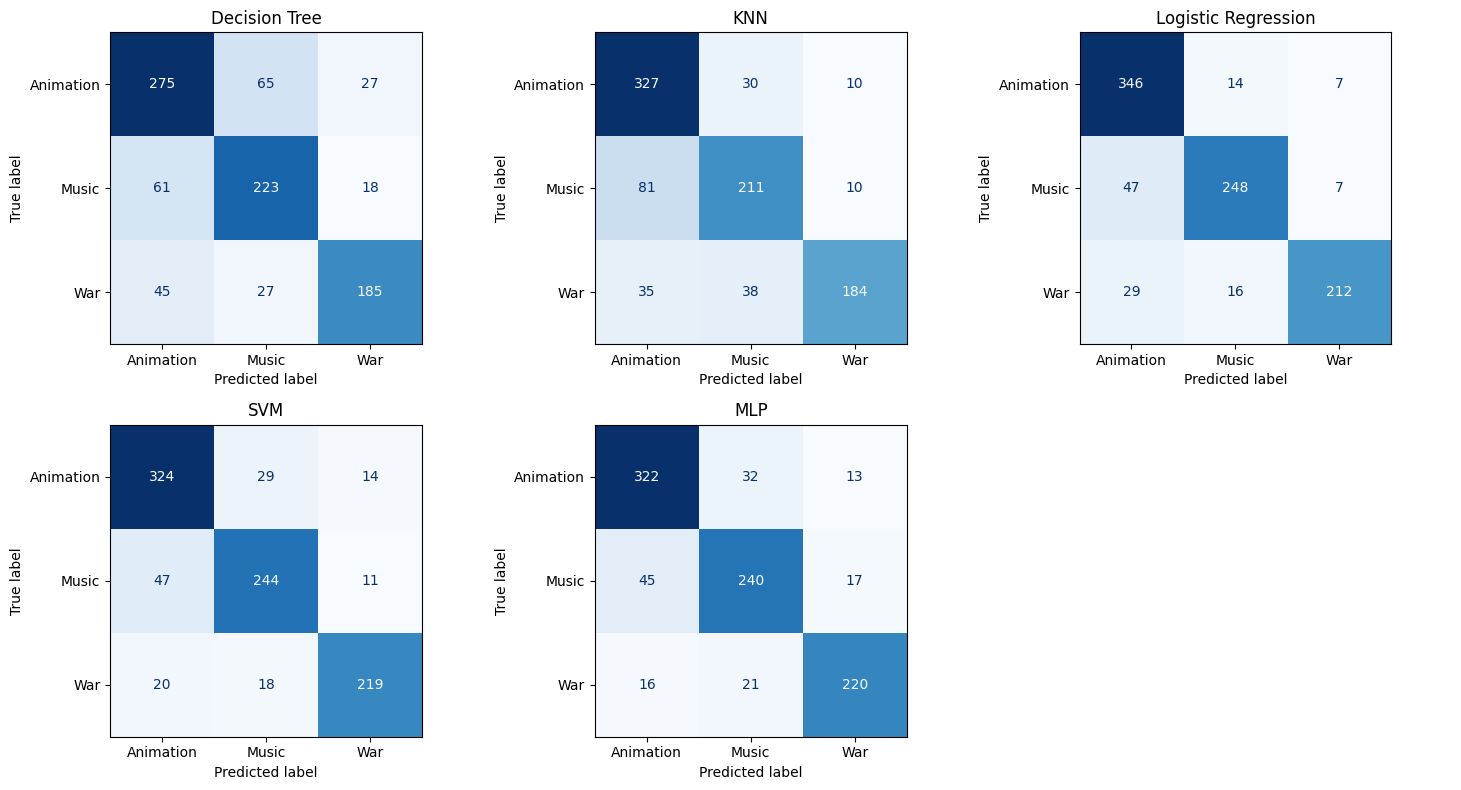

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

def plot_confusion_matrices(models, X_test, y_test, class_names, n_cols=3):
    n_models = len(models)
    n_rows = (n_models + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.flatten()

    for ax, (name, model) in zip(axes, models.items()):
        ConfusionMatrixDisplay.from_estimator(
            model,
            X_test,
            y_test,
            display_labels=class_names,
            cmap="Blues",
            ax=ax,
            colorbar=False
        )
        ax.set_title(name)

    # Remove empty subplots
    for ax in axes[len(models):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_confusion_matrices(
    models=models,
    X_test=X_test,
    y_test=y_test,
    class_names=le.classes_
)


In [28]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall
0,Decision Tree,0.737581,0.744690,0.735858
1,KNN,0.779698,0.798794,0.768546
2,Logistic Regression,0.870410,0.883348,0.862958
3,SVM,0.849892,0.854891,0.847640
4,MLP,0.844492,0.846615,0.842706


In [ ]:
Το καλύτερο μοντέλο με βάση αυτά τα αποτελέσματα είναι το Logistic Regression, ενώ το χειρότερο είναι το Decision tree.

#### word2vec embedding

In [29]:
import gensim.downloader as api

glove = api.load("glove-wiki-gigaword-50")  # 50-dim embeddings

[==================================================] 100.0% 66.0/66.0MB downloaded


In [32]:
df_filtered["overview"]

,overview
0,"Led by Woody, Andy's toys live happily in his ..."
12,An outcast half-wolf risks his life to prevent...
40,Shakespeare's Play transplanted into a 1930s s...
47,History comes gloriously to life in Disney's e...
61,"In 1965, passionate musician Glenn Holland tak..."
...,...
45386,An abstract animation from Walter Ruttmann.
45388,An abstract animation by Walter Ruttmann.
45433,No overview found.
45437,A closeted boy runs the risk of being outed by...


In [45]:
import re
from gensim.models import Word2Vec
import numpy as np

import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", "", text)
    tokens = [
        word for word in text.split()
        if word not in ENGLISH_STOP_WORDS
    ]
    return tokens

def document_mean_vector(text, model):
    tokens = tokenize(text)

    vectors = [
        model[word]
        for word in tokens
        if word in model
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

X_w2v = np.vstack(
    df_nlp["overview"].apply(
        lambda text: document_mean_vector(text, glove)
    )
)
X_w2v.shape


(4630, 50)

In [46]:
from sklearn.model_selection import train_test_split
le = LabelEncoder()
y = le.fit_transform(df_filtered["kept_genre"])

X_train_w2v, X_test_w2v, y_train, y_test = train_test_split(
    X_w2v,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


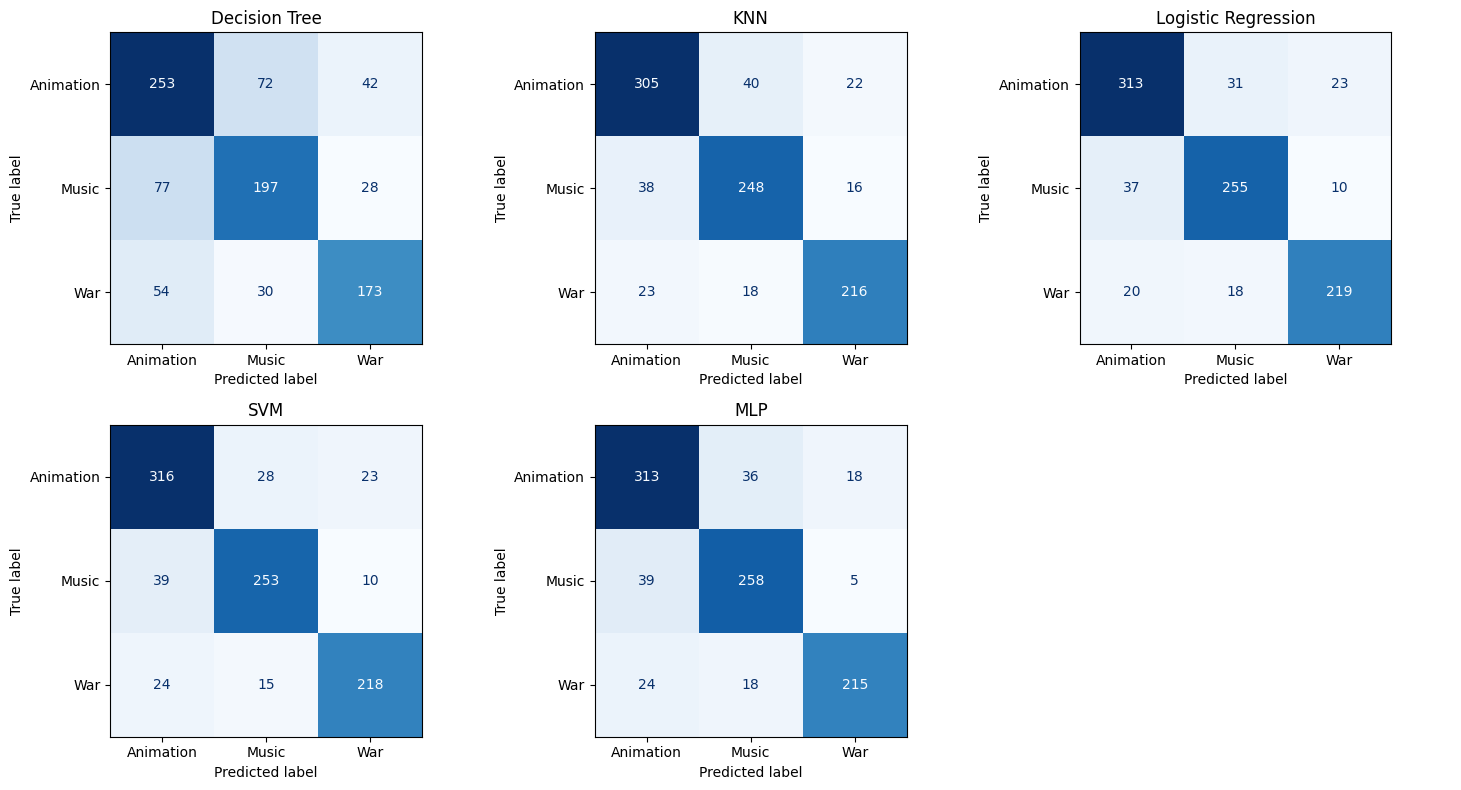

In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier


def get_models(random_state=42):
    return {
        "Decision Tree": DecisionTreeClassifier(random_state=random_state),
        "KNN": KNeighborsClassifier(n_neighbors=5, metric="cosine"),
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "SVM": LinearSVC(),
        "MLP": MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=random_state)
    }

def fit_models(models, X_train, y_train):
    fitted_models = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        fitted_models[name] = model
    return fitted_models

def plot_confusion_matrices(models, X_test, y_test, class_names, n_cols=3):
    n_models = len(models)
    n_rows = (n_models + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4 * n_rows)
    )

    axes = axes.flatten()

    for ax, (name, model) in zip(axes, models.items()):
        ConfusionMatrixDisplay.from_estimator(
            model,
            X_test,
            y_test,
            display_labels=class_names,
            cmap="Blues",
            ax=ax,
            colorbar=False
        )
        ax.set_title(name)

    # Hide unused subplots
    for ax in axes[len(models):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


models = get_models()

models_w2v = fit_models(
    models=models,
    X_train=X_train_w2v,
    y_train=y_train
)

plot_confusion_matrices(
    models=models_w2v,
    X_test=X_test_w2v,
    y_test=y_test,
    class_names=le.classes_
)

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

def evaluate_models(models, X_test, y_test):
    results = []

    for name, model in models.items():
        y_pred = model.predict(X_test)

        results.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="macro"),
            "Recall": recall_score(y_test, y_pred, average="macro")
        })

    return pd.DataFrame(results)


results_w2v_df = evaluate_models(
    models=models_w2v,
    X_test=X_test_w2v,
    y_test=y_test
)

results_w2v_df

,Model,Accuracy,Precision,Recall
0,Decision Tree,0.672786,0.676550,0.671614
1,KNN,0.830454,0.831395,0.830907
2,Logistic Regression,0.849892,0.851270,0.849791
3,SVM,0.849892,0.852343,0.849011
4,MLP,0.848812,0.854244,0.847914


Τα καλύτερα μοντέλα είναι τα Logistic Regression (όπως και με tfidf) και SVM, με διαφορές στα precision και recall.

#### Σχολιασμός αποτελεσμάτων - σύγκριση tfidf/word2vec

Σε σχέση με τα αποτελέσματα που εμφανίζει το evaluation του tfidf, το word2vec μοντέλο που χρησιμοποιήθηκε βελτιώνει το μοντέλο knn επειδή τα διανύσματα βοηθάνε στην καλύτερη ομαδοποίηση σε clusters, ενώ παρουσιάζει χειρότερα αποτελέσματα από το tfidf στο μοντέλο decision tree, καθώς λόγω της πυκνότητας του word2vec είναι πιο δύσκολο να γίνει το split σε πολλαπλές διακλαδώσεις.
Στα υπόλοιπα μοντέλα δεν παρατηρείται μεγάλη διαφορά στα δεκαδικά των αποτελεσμάτων.


# UCF using pagerank (question 4)

In [49]:
import pandas as pd

df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data_train.csv")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/data_test.csv")

In [50]:
import numpy as np
from scipy.sparse import csr_matrix
import networkx as nx
from sklearn.metrics.pairwise import cosine_similarity

# unique users & movies
user_ids  = df_train["uid"].unique()
movie_ids = df_train["mid"].unique()

user_map  = {u: i for i, u in enumerate(user_ids)}
movie_map = {m: i for i, m in enumerate(movie_ids)}

rows = df_train["uid"].map(user_map).values
cols = df_train["mid"].map(movie_map).values
vals = df_train["rating"].values

R = csr_matrix(
    (vals, (rows, cols)),
    shape=(len(user_ids), len(movie_ids)))

In [51]:
def build_graph(R, m):

    G = nx.Graph()
    num_users = R.shape[0]

    for u in range(num_users):
        # cosine similarity of user u to all users
        sims = cosine_similarity(
            R[u],
            R,
            dense_output=False
        ).toarray().ravel()

        # remove self similarity
        sims[u] = 0

        # top-m neighbors
        top_idx = np.argpartition(sims, -m)[-m:]

        for v in top_idx:
            if sims[v] > 0:
                G.add_edge(u, v, weight=sims[v])

    return G


In [52]:
m_values = [3, 5, 10]

graphs = {}

for m in m_values:
    G = build_graph(R, m)
    graphs[m] = G

In [53]:
import networkx as nx

def personalized_pagerank_scores(G, u, alpha=0.85):
    personalization = {n: 0 for n in G.nodes()}
    personalization[u] = 1 #probability of starting from this node becomes 1
    return nx.pagerank(G, alpha=alpha, personalization=personalization, weight='weight')

In [54]:
scores = personalized_pagerank_scores(graphs[5], u=10) # computes pagerank for user with id 10 as example

In [85]:
import numpy as np
from sklearn.metrics import mean_squared_error
import networkx as nx

# --- Helper functions ---
def user_mean(R_csc, u):
    row = R_csc[u]
    return row.data.mean() if row.nnz > 0 else 0.0

def ucf_with_ppr(u, m, k_list, R_csc, ppr_scores, user_means):
    # Users who rated movie m
    m_users = R_csc[:, m].indices
    if len(m_users) == 0:
        # no one rated this movie -> return user mean for all k
        return {k: user_means[u] for k in k_list}

    sims = []
    ratings = []

    for v in m_users:
        if v == u:
            continue
        sim = ppr_scores.get(v, 0.0)  # similarity of u->v
        if sim > 0:
            sims.append(sim)
            ratings.append(R_csc[v, m] - user_means[v])  # centered rating

    if len(sims) == 0:
        # no similar users -> return user mean for all k
        return {k: user_means[u] for k in k_list}

    sims = np.array(sims)
    ratings = np.array(ratings)

    # Sort by similarity descending
    order = np.argsort(-sims)
    sims = sims[order]
    ratings = ratings[order]

    # Cumulative sums for fast top-k computation
    num = np.cumsum(sims * ratings)
    den = np.cumsum(np.abs(sims))

    preds = {}
    for k in k_list:
        if k > len(den) or den[k - 1] == 0:
            preds[k] = user_means[u]
        else:
            preds[k] = user_means[u] + num[k - 1] / den[k - 1]

    return preds

# --- Main evaluation loop ---
def evaluate_ucf_with_ppr(R_csc, df_test, k_list):
    # Precompute user means
    user_means = np.zeros(R_csc.shape[0])
    for u in range(R_csc.shape[0]):
        user_means[u] = user_mean(R_csc, u)

    # Prepare per-k prediction storage
    preds_per_k = {k: [] for k in k_list}
    true = []

    for u, m, r in zip(df_test.uid, df_test.mid, df_test.rating):
        if u >= R_csc.shape[0] or m >= R_csc.shape[1]:
            continue  # skip out-of-bound indices

        # --- Compute Personalized PageRank for this user ---
        personalization = {n: 0 for n in range(R_csc.shape[0])}
        personalization[u] = 1
        ppr_scores = nx.pagerank(G, alpha=0.85, personalization=personalization, weight='weight')

        # --- Get predictions for all k ---
        preds_u = ucf_with_ppr(u, m, k_list, R_csc, ppr_scores, user_means)

        for k in k_list:
            preds_per_k[k].append(preds_u[k])

        true.append(r)

    # Compute RMSE per k
    rmse_per_k = {}
    for k in k_list:
        rmse_per_k[k] = np.sqrt(mean_squared_error(true, preds_per_k[k]))

    return rmse_per_k

# --- Example usage ---
k_list = [1,2,3,5,10,20,30,40,50,60,70,80,90,100]

# Convert ratings to CSC matrix
R_csc = R.tocsc()

# Assume G is your user similarity graph already built (edges weighted by cosine similarity)
rmse_results = evaluate_ucf_with_ppr(R_csc, df_test, k_list)




In [88]:
all_rmse = []

for k in k_list:
    print(f"k={k}, RMSE={rmse_results[k]:.4f}")
    all_rmse.append(rmse_results[k])


k=1, RMSE=1.5062
k=2, RMSE=1.3638
k=3, RMSE=1.3172
k=5, RMSE=1.2670
k=10, RMSE=1.2215
k=20, RMSE=1.1913
k=30, RMSE=1.1758
k=40, RMSE=1.1649
k=50, RMSE=1.1606
k=60, RMSE=1.1566
k=70, RMSE=1.1549
k=80, RMSE=1.1536
k=90, RMSE=1.1521
k=100, RMSE=1.1518


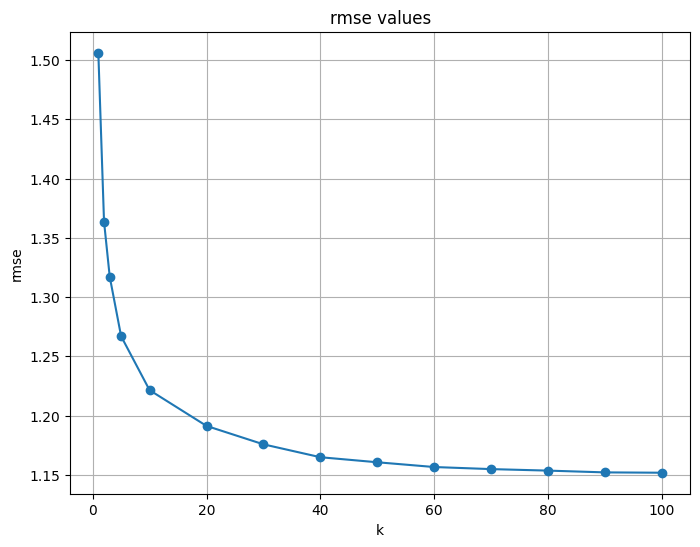

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# data to be plotted

x = k_list        # ensures shape (14,)
y = all_rmse

plt.figure(figsize=(8, 6))
plt.plot(x, y, marker='o', linestyle='-')


plt.title('rmse values')
plt.xlabel('k')
plt.ylabel('rmse')

plt.grid(True)
plt.show()

Η μικρότερη τιμή του RMSE για αυτήν την ανάλυση (περίπου 1.15) είναι καλύτερη από αυτή της δεύτερης άσκησης (περίπου 1.3). Αυτό συμβαίνει εξαιτίας της χρήσης του pagerank εκτός απο cosine similarity σε αυτήν την ανάλυση σε αντίθεση με την προηγούμενη, κάτι το οποίο βοηθάει στην σύνδεση μεταξύ περισσότερων χρηστών στο δίκτυο και άρα μία καλύτερη αξιολόγηση των δεδομένων.